[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jermrodrr/BIG-DATA/blob/main/Bank_Marketing_Clustering.ipynb)

# Clustering de datos mixtos — Bank Marketing (UCI)

Se comparan tres métodos:

- **K-Prototypes**
- **K-Means + One-Hot Encoding**
- **K-Means + MCA**

El dataset utilizado es **Bank Marketing — bank-full.csv**, obtenido
directamente del **UCI Machine Learning Repository**.

La selección se realiza con **Silueta usando distancia Gower** y
**Calinski-Harabasz**. La variable real `y` no participa en el clustering
y solo se utiliza al final para comprobar el desempeño fuera de muestra.


In [1]:
# ============================================================
# 1. LIBRERÍAS, PARÁMETROS Y PALETA VISUAL
# ============================================================

%pip install -q kmodes prince gower

import io
import time
import zipfile
import warnings
from urllib.request import Request, urlopen
from IPython.display import display, HTML, Markdown

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

import gower
import prince
from kmodes.kprototypes import KPrototypes

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    accuracy_score
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    MinMaxScaler,
    RobustScaler,
    StandardScaler,
    OneHotEncoder
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
MODEL_SAMPLE_SIZE = 4_000
EVALUATION_SAMPLE_SIZE = 1_000
PLOT_SAMPLE_SIZE = 2_500
K_VALUES = range(2, 11)
N_MCA_COMPONENTS = 8

COLORS = {
    "gold_light": "#FFD60A",
    "gold": "#FFC300",
    "ocean_navy": "#003566",
    "deep_navy": "#001D3D",
    "midnight": "#000814",
    "white": "#FFFFFF",
    "gray": "#E9ECEF"
}

PALETTE = [
    COLORS["gold_light"],
    COLORS["gold"],
    COLORS["ocean_navy"],
    COLORS["deep_navy"],
    COLORS["midnight"]
]

MODEL_COLORS = {
    "K-Prototypes": COLORS["gold"],
    "K-Means + One-Hot": COLORS["ocean_navy"],
    "K-Means + MCA": COLORS["deep_navy"]
}

pio.templates["golden_twilight"] = go.layout.Template(
    layout=go.Layout(
        colorway=PALETTE,
        paper_bgcolor=COLORS["white"],
        plot_bgcolor=COLORS["white"],
        font=dict(
            family="Arial",
            size=13,
            color=COLORS["deep_navy"]
        ),
        title=dict(
            font=dict(size=22, color=COLORS["midnight"]),
            x=0.05
        ),
        xaxis=dict(
            showgrid=False,
            linecolor=COLORS["deep_navy"]
        ),
        yaxis=dict(
            gridcolor="rgba(0,53,102,0.12)",
            linecolor=COLORS["deep_navy"]
        )
    )
)

pio.templates.default = "golden_twilight"

plt.rcParams.update({
    "figure.figsize": (10, 7),
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titleweight": "bold",
    "axes.titlesize": 16,
    "axes.titlecolor": COLORS["midnight"],
    "axes.labelcolor": COLORS["deep_navy"],
    "xtick.color": COLORS["deep_navy"],
    "ytick.color": COLORS["deep_navy"]
})

golden_twilight_cmap = LinearSegmentedColormap.from_list(
    "golden_twilight",
    PALETTE
)

def create_ohe():
    """OneHotEncoder compatible con distintas versiones de sklearn."""
    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False,
            dtype=np.float32
        )
    except TypeError:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse=False,
            dtype=np.float32
        )

def add_space(height=34):
    """Agrega separación visual entre tablas, gráficos y textos."""
    display(
        HTML(
            f"<div style='height:{height}px'></div>"
        )
    )


def show_interpretation(title, text):
    """Muestra una interpretación legible dentro del notebook."""
    display(
        Markdown(
            f"### {title}\n\n{text}"
        )
    )
    add_space(28)

print("Configuración lista.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 3.6 MB/s eta 0:00:00
Configuración lista.


## 2. Carga y preparación

Se descarga `bank-full.csv` desde el repositorio oficial UCI.  
`duration` se conserva para la exploración, pero se excluye del clustering porque solo se conoce después de la llamada.


In [2]:
# ============================================================
# 2. DESCARGA DESDE UCI Y PREPARACIÓN
# ============================================================

UCI_DOWNLOAD_URL = (
    "https://archive.ics.uci.edu/static/public/222/"
    "bank%2Bmarketing.zip"
)

request = Request(
    UCI_DOWNLOAD_URL,
    headers={"User-Agent": "Mozilla/5.0"}
)

with urlopen(request, timeout=120) as response:
    downloaded_bytes = response.read()

df = None
selected_path = None

with zipfile.ZipFile(io.BytesIO(downloaded_bytes)) as outer_zip:
    outer_names = outer_zip.namelist()

    direct_csv = [
        name for name in outer_names
        if name.lower().endswith("bank-full.csv")
    ]

    if direct_csv:
        selected_path = direct_csv[0]

        with outer_zip.open(selected_path) as csv_file:
            df = pd.read_csv(csv_file, sep=";")

    else:
        nested_zips = [
            name for name in outer_names
            if name.lower().endswith(".zip")
        ]

        for nested_zip_name in nested_zips:
            nested_bytes = outer_zip.read(nested_zip_name)

            with zipfile.ZipFile(io.BytesIO(nested_bytes)) as nested_zip:
                csv_candidates = [
                    name for name in nested_zip.namelist()
                    if name.lower().endswith("bank-full.csv")
                ]

                if csv_candidates:
                    csv_name = csv_candidates[0]

                    with nested_zip.open(csv_name) as csv_file:
                        df = pd.read_csv(csv_file, sep=";")

                    selected_path = f"{nested_zip_name} → {csv_name}"
                    break

if df is None:
    raise FileNotFoundError("No fue posible encontrar bank-full.csv.")

if df.shape != (45_211, 17):
    raise ValueError(
        f"Se esperaba (45211, 17), pero se obtuvo {df.shape}."
    )

df_clean = (
    df.drop_duplicates()
    .reset_index(drop=True)
)

# Se reserva para la validación final.
y = df_clean["y"].copy()
y_bin = y.map({"no": 0, "yes": 1})

# duration no participa en el clustering.
X = df_clean.drop(columns=["y", "duration"]).copy()

# pdays = -1 significa que nunca hubo contacto anterior.
X["previously_contacted"] = np.where(
    X["pdays"].eq(-1),
    "no",
    "yes"
)

X["pdays"] = X["pdays"].replace(-1, 0)

numeric_columns = (
    X.select_dtypes(include=np.number)
    .columns
    .tolist()
)

categorical_columns = (
    X.select_dtypes(exclude=np.number)
    .columns
    .tolist()
)

X[categorical_columns] = X[categorical_columns].astype(str)

summary = pd.DataFrame({
    "Indicador": [
        "Dataset",
        "Fuente",
        "Clientes",
        "Variables para clustering",
        "Variables numéricas",
        "Variables categóricas",
        "Duplicados eliminados",
        "Valores faltantes"
    ],
    "Resultado": [
        "Bank Marketing — bank-full.csv",
        "UCI Machine Learning Repository",
        len(X),
        X.shape[1],
        len(numeric_columns),
        len(categorical_columns),
        len(df) - len(df_clean),
        int(X.isna().sum().sum())
    ]
})

display(summary)
add_space()
display(df_clean.head())
add_space()

print("Numéricas:", numeric_columns)
print("Categóricas:", categorical_columns)


show_interpretation(
    "Interpretación de la preparación",
    (
        f"El dataset **Bank Marketing — bank-full.csv**, obtenido del **UCI Machine Learning Repository**, contiene **{len(df_clean):,} clientes**. "
        f"Para formar los clústeres se utilizan **{len(numeric_columns)} "
        f"variables numéricas** y **{len(categorical_columns)} categóricas**. "
        "`duration` se mantiene únicamente para la exploración porque se conoce "
        "después de realizar la llamada. La variable real `y` permanece separada "
        "y no interviene en la formación ni en la selección de los clústeres. "
        "Además, `pdays = -1` se convirtió en una categoría explícita mediante "
        "`previously_contacted`, evitando interpretar ese código como una cantidad "
        "real de días."
    )
)


,Indicador,Resultado
0,Dataset,Bank Marketing — bank-full.csv
1,Fuente,UCI Machine Learning Repository
2,Clientes,45211
3,Variables para clustering,16
4,Variables numéricas,6
5,Variables categóricas,10
6,Duplicados eliminados,0
7,Valores faltantes,0


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


Numéricas: ['age', 'balance', 'day', 'campaign', 'pdays', 'previous']
Categóricas: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'previously_contacted']


### Interpretación de la preparación

El dataset **Bank Marketing — bank-full.csv**, obtenido del **UCI Machine Learning Repository**, contiene **45,211 clientes**. Para formar los clústeres se utilizan **6 variables numéricas** y **10 categóricas**. `duration` se mantiene únicamente para la exploración porque se conoce después de realizar la llamada. La variable real `y` permanece separada y no interviene en la formación ni en la selección de los clústeres. Además, `pdays = -1` se convirtió en una categoría explícita mediante `previously_contacted`, evitando interpretar ese código como una cantidad real de días.

## 3. Exploración

Se conservan los gráficos principales: resumen del dataset, distribución con boxplot, heatmap de correlación y número de categorías.


### Interpretación de la composición

El conjunto preparado combina **6 variables numéricas** y **10 categóricas**. Esta mezcla justifica la comparación entre K-Prototypes, que conserva ambos tipos por separado, y las alternativas que transforman las categorías antes de aplicar K-Means.

### Interpretación de las distribuciones

El menú permite revisar cada variable numérica sin generar gráficos repetidos. El histograma muestra la concentración, la asimetría y los posibles grupos internos; el boxplot resume la mediana, los cuartiles y los valores extremos. Los valores extremos no se eliminan automáticamente porque pueden representar comportamientos reales de clientes, especialmente en `balance`, `campaign`, `pdays` y `previous`.

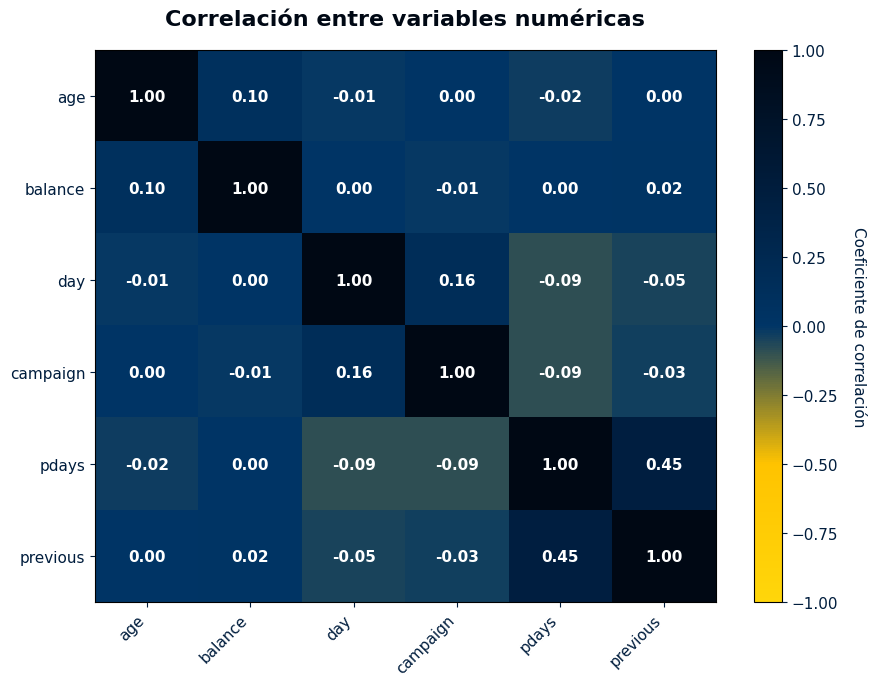

### Interpretación del heatmap

La relación lineal más alta entre variables distintas aparece entre **pdays** y **previous**, con una correlación de **0.45**. El heatmap no se utiliza para eliminar variables de manera automática; sirve para detectar relaciones que podrían influir en la forma de los grupos.

### Interpretación de las variables categóricas

La variable con mayor variedad es **job**, con **12 categorías**. Una variable con muchas categorías genera más columnas al utilizar One-Hot Encoding; por eso se equilibra su contribución antes de aplicar K-Means. K-Prototypes, en cambio, conserva estas categorías sin expandirlas en columnas binarias.

In [3]:
# ============================================================
# 3. EXPLORACIÓN GRÁFICA
# ============================================================

# ------------------------------------------------------------
# 3.1 Composición de variables
# ------------------------------------------------------------

variable_types = pd.DataFrame({
    "Tipo": ["Numéricas", "Categóricas"],
    "Cantidad": [
        len(numeric_columns),
        len(categorical_columns)
    ]
})

fig = px.bar(
    variable_types,
    x="Tipo",
    y="Cantidad",
    color="Tipo",
    text="Cantidad",
    color_discrete_map={
        "Numéricas": COLORS["gold"],
        "Categóricas": COLORS["ocean_navy"]
    },
    title="Composición de variables para el clustering"
)

fig.update_traces(
    textposition="outside",
    hovertemplate="<b>%{x}</b><br>Cantidad: %{y}<extra></extra>"
)

fig.update_layout(
    height=480,
    showlegend=False,
    xaxis_title="Tipo de variable",
    yaxis_title="Cantidad"
)

fig.show()
add_space()

show_interpretation(
    "Interpretación de la composición",
    (
        f"El conjunto preparado combina **{len(numeric_columns)} variables "
        f"numéricas** y **{len(categorical_columns)} categóricas**. "
        "Esta mezcla justifica la comparación entre K-Prototypes, que conserva "
        "ambos tipos por separado, y las alternativas que transforman las "
        "categorías antes de aplicar K-Means."
    )
)

# ------------------------------------------------------------
# 3.2 Histograma y boxplot dinámico
# ------------------------------------------------------------

numeric_eda_columns = (
    df_clean.select_dtypes(include=np.number)
    .columns
    .tolist()
)

fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.12,
    row_heights=[0.70, 0.30],
    subplot_titles=[
        "Distribución de frecuencias",
        "Boxplot y valores extremos"
    ]
)

for position, column in enumerate(numeric_eda_columns):
    visible = position == 0
    current_color = PALETTE[position % len(PALETTE)]

    fig.add_trace(
        go.Histogram(
            x=df_clean[column],
            nbinsx=45,
            name=f"Distribución de {column}",
            visible=visible,
            marker=dict(
                color=current_color,
                line=dict(color=COLORS["white"], width=0.5)
            ),
            opacity=0.90,
            hovertemplate=(
                f"<b>{column}</b><br>"
                "Valor: %{x}<br>"
                "Frecuencia: %{y:,}<extra></extra>"
            )
        ),
        row=1,
        col=1
    )

    fig.add_trace(
        go.Box(
            x=df_clean[column],
            name=column,
            visible=visible,
            orientation="h",
            boxpoints="outliers",
            marker=dict(
                color=current_color,
                size=5,
                opacity=0.65
            ),
            line=dict(
                color=COLORS["midnight"],
                width=2
            ),
            fillcolor=current_color,
            hovertemplate=(
                f"<b>{column}</b><br>"
                "Valor: %{x}<extra></extra>"
            )
        ),
        row=2,
        col=1
    )

buttons = []

for selected_position, column in enumerate(numeric_eda_columns):
    visibility = []

    for trace_position in range(len(numeric_eda_columns)):
        selected = trace_position == selected_position
        visibility.extend([selected, selected])

    buttons.append(
        dict(
            label=column,
            method="update",
            args=[
                {"visible": visibility},
                {"title": f"Distribución y boxplot de {column}"}
            ]
        )
    )

fig.update_layout(
    title=f"Distribución y boxplot de {numeric_eda_columns[0]}",
    height=720,
    showlegend=False,
    bargap=0.04,
    updatemenus=[
        dict(
            type="dropdown",
            buttons=buttons,
            direction="down",
            showactive=True,
            x=1,
            xanchor="right",
            y=1.18,
            yanchor="top",
            bgcolor=COLORS["gold_light"],
            bordercolor=COLORS["deep_navy"],
            borderwidth=1
        )
    ],
    annotations=[
        dict(
            text="Selecciona una variable:",
            x=0.70,
            y=1.155,
            xref="paper",
            yref="paper",
            showarrow=False
        )
    ]
)

fig.update_yaxes(title_text="Frecuencia", row=1, col=1)
fig.update_xaxes(title_text="Valor observado", row=2, col=1)
fig.show()
add_space()

show_interpretation(
    "Interpretación de las distribuciones",
    (
        "El menú permite revisar cada variable numérica sin generar gráficos "
        "repetidos. El histograma muestra la concentración, la asimetría y los "
        "posibles grupos internos; el boxplot resume la mediana, los cuartiles "
        "y los valores extremos. Los valores extremos no se eliminan "
        "automáticamente porque pueden representar comportamientos reales de "
        "clientes, especialmente en `balance`, `campaign`, `pdays` y `previous`."
    )
)

# ------------------------------------------------------------
# 3.3 Heatmap de correlación
# ------------------------------------------------------------

correlation_matrix = X[numeric_columns].corr()

figure, axis = plt.subplots(figsize=(9, 7))

heatmap = axis.imshow(
    correlation_matrix,
    cmap=golden_twilight_cmap,
    vmin=-1,
    vmax=1,
    aspect="auto"
)

axis.set_xticks(np.arange(len(numeric_columns)))
axis.set_yticks(np.arange(len(numeric_columns)))

axis.set_xticklabels(
    numeric_columns,
    rotation=45,
    ha="right"
)

axis.set_yticklabels(numeric_columns)

normalizer = plt.Normalize(vmin=-1, vmax=1)

for row in range(correlation_matrix.shape[0]):
    for column in range(correlation_matrix.shape[1]):
        value = correlation_matrix.iloc[row, column]

        background_color = golden_twilight_cmap(
            normalizer(value)
        )

        red, green, blue = background_color[:3]

        luminance = (
            0.299 * red
            + 0.587 * green
            + 0.114 * blue
        )

        text_color = (
            COLORS["white"]
            if luminance < 0.48
            else COLORS["midnight"]
        )

        axis.text(
            column,
            row,
            f"{value:.2f}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=11,
            fontweight="bold"
        )

axis.set_title(
    "Correlación entre variables numéricas",
    pad=18
)

colorbar = figure.colorbar(heatmap, ax=axis)
colorbar.set_label(
    "Coeficiente de correlación",
    rotation=270,
    labelpad=20
)

figure.tight_layout()
plt.show()
add_space()

upper_triangle = (
    correlation_matrix
    .where(
        np.triu(
            np.ones(correlation_matrix.shape),
            k=1
        ).astype(bool)
    )
)

strongest_pair = (
    upper_triangle
    .abs()
    .stack()
    .idxmax()
)

strongest_value = correlation_matrix.loc[
    strongest_pair[0],
    strongest_pair[1]
]

show_interpretation(
    "Interpretación del heatmap",
    (
        f"La relación lineal más alta entre variables distintas aparece entre "
        f"**{strongest_pair[0]}** y **{strongest_pair[1]}**, con una correlación "
        f"de **{strongest_value:.2f}**. El heatmap no se utiliza para eliminar "
        "variables de manera automática; sirve para detectar relaciones que "
        "podrían influir en la forma de los grupos."
    )
)

# ------------------------------------------------------------
# 3.4 Número de categorías
# ------------------------------------------------------------

category_count = pd.DataFrame({
    "Variable": categorical_columns,
    "Categorías": [
        X[column].nunique()
        for column in categorical_columns
    ]
}).sort_values(
    "Categorías",
    ascending=False
)

fig = px.bar(
    category_count,
    x="Variable",
    y="Categorías",
    text="Categorías",
    color="Categorías",
    color_continuous_scale=[
        [0.00, COLORS["gold_light"]],
        [0.25, COLORS["gold"]],
        [0.50, COLORS["ocean_navy"]],
        [0.75, COLORS["deep_navy"]],
        [1.00, COLORS["midnight"]]
    ],
    title="Número de categorías por variable"
)

fig.update_traces(
    textposition="outside",
    hovertemplate="<b>%{x}</b><br>Categorías: %{y}<extra></extra>"
)

fig.update_layout(
    height=520,
    coloraxis_showscale=False,
    xaxis_title="Variable categórica",
    yaxis_title="Cantidad de categorías"
)

fig.show()
add_space()

highest_cardinality = category_count.iloc[0]

show_interpretation(
    "Interpretación de las variables categóricas",
    (
        f"La variable con mayor variedad es **{highest_cardinality['Variable']}**, "
        f"con **{int(highest_cardinality['Categorías'])} categorías**. "
        "Una variable con muchas categorías genera más columnas al utilizar "
        "One-Hot Encoding; por eso se equilibra su contribución antes de aplicar "
        "K-Means. K-Prototypes, en cambio, conserva estas categorías sin "
        "expandirlas en columnas binarias."
    )
)


## 4. Preparación de las tres representaciones

Se utiliza una muestra para seleccionar el método y el número de clústeres.  
La misma muestra de evaluación se usa para Silueta Gower y Calinski-Harabasz.


In [4]:
# ============================================================
# 4. PREPARACIÓN DE K-PROTOTYPES, ONE-HOT, MCA Y GOWER
# ============================================================

model_indices = X.sample(
    n=min(MODEL_SAMPLE_SIZE, len(X)),
    random_state=RANDOM_STATE
).index

X_model = (
    X.loc[model_indices]
    .copy()
    .reset_index(drop=True)
)

# Control de valores extremos sin eliminar clientes.
lower_bounds = X_model[numeric_columns].quantile(0.01)
upper_bounds = X_model[numeric_columns].quantile(0.99)

X_model[numeric_columns] = (
    X_model[numeric_columns]
    .clip(
        lower=lower_bounds,
        upper=upper_bounds,
        axis=1
    )
)

# ------------------------------------------------------------
# K-Means + One-Hot
# ------------------------------------------------------------

ohe_scaler = MinMaxScaler()
ohe_encoder = create_ohe()

X_num_ohe = ohe_scaler.fit_transform(
    X_model[numeric_columns]
).astype(np.float32)

X_cat_ohe = ohe_encoder.fit_transform(
    X_model[categorical_columns]
).astype(np.float32)

# Un cambio de categoría aporta una distancia comparable.
X_cat_ohe = X_cat_ohe / np.sqrt(2)

X_ohe = np.hstack([
    X_num_ohe,
    X_cat_ohe
]).astype(np.float32)

# ------------------------------------------------------------
# K-Prototypes
# ------------------------------------------------------------

kproto_scaler = RobustScaler()

X_num_kproto = kproto_scaler.fit_transform(
    X_model[numeric_columns]
)

X_cat_kproto = (
    X_model[categorical_columns]
    .to_numpy(dtype=object)
)

X_kproto = np.column_stack([
    X_num_kproto,
    X_cat_kproto
]).astype(object)

categorical_indices = list(
    range(
        len(numeric_columns),
        len(numeric_columns) + len(categorical_columns)
    )
)

# ------------------------------------------------------------
# K-Means + MCA
# ------------------------------------------------------------

maximum_components = int(
    sum(
        X_model[column].nunique() - 1
        for column in categorical_columns
    )
)

mca_components = max(
    2,
    min(N_MCA_COMPONENTS, maximum_components)
)

mca_model = prince.MCA(
    n_components=mca_components,
    n_iter=5,
    engine="sklearn",
    random_state=RANDOM_STATE
)

X_mca_coordinates = np.asarray(
    mca_model.fit_transform(
        X_model[categorical_columns]
    ),
    dtype=np.float32
)

mca_num_scaler = StandardScaler()
mca_cat_scaler = StandardScaler()

X_num_mca = mca_num_scaler.fit_transform(
    X_model[numeric_columns]
).astype(np.float32)

X_cat_mca = mca_cat_scaler.fit_transform(
    X_mca_coordinates
).astype(np.float32)

X_mca = np.hstack([
    X_num_mca / np.sqrt(X_num_mca.shape[1]),
    X_cat_mca / np.sqrt(X_cat_mca.shape[1])
]).astype(np.float32)

# ------------------------------------------------------------
# Muestra común para las métricas
# ------------------------------------------------------------

rng = np.random.default_rng(RANDOM_STATE)

evaluation_positions = np.sort(
    rng.choice(
        len(X_model),
        size=min(EVALUATION_SAMPLE_SIZE, len(X_model)),
        replace=False
    )
)

X_gower = X_model.iloc[
    evaluation_positions
][numeric_columns + categorical_columns]

categorical_mask = np.array(
    [False] * len(numeric_columns)
    + [True] * len(categorical_columns)
)

print("Calculando matriz Gower...")

gower_distance_matrix = gower.gower_matrix(
    X_gower,
    cat_features=categorical_mask
)

np.fill_diagonal(gower_distance_matrix, 0)

# Espacio numérico común para Calinski-Harabasz.
X_common_evaluation = X_ohe[evaluation_positions]

display(pd.DataFrame({
    "Método": [
        "K-Prototypes",
        "K-Means + One-Hot",
        "K-Means + MCA"
    ],
    "Filas": [
        X_kproto.shape[0],
        X_ohe.shape[0],
        X_mca.shape[0]
    ],
    "Columnas": [
        X_kproto.shape[1],
        X_ohe.shape[1],
        X_mca.shape[1]
    ]
}))
add_space()

print("Matriz Gower:", gower_distance_matrix.shape)
add_space()

show_interpretation(
    "Interpretación del preprocesamiento",
    (
        f"Los tres métodos utilizan los mismos **{len(X_model):,} clientes** "
        "durante la selección. K-Prototypes conserva las variables mixtas; "
        "One-Hot genera una representación binaria; y MCA resume la información "
        f"categórica en **{mca_components} componentes**. La Silueta se evalúa "
        f"con una matriz Gower común de **{gower_distance_matrix.shape[0]:,} × "
        f"{gower_distance_matrix.shape[1]:,}**, mientras que "
        "Calinski-Harabasz utiliza el mismo espacio numérico para las etiquetas "
        "de los tres modelos."
    )
)


Calculando matriz Gower...


,Método,Filas,Columnas
0,K-Prototypes,4000,16
1,K-Means + One-Hot,4000,52
2,K-Means + MCA,4000,14


Matriz Gower: (1000, 1000)


### Interpretación del preprocesamiento

Los tres métodos utilizan los mismos **4,000 clientes** durante la selección. K-Prototypes conserva las variables mixtas; One-Hot genera una representación binaria; y MCA resume la información categórica en **8 componentes**. La Silueta se evalúa con una matriz Gower común de **1,000 × 1,000**, mientras que Calinski-Harabasz utiliza el mismo espacio numérico para las etiquetas de los tres modelos.

## 5. Entrenamiento y evaluación

Para cada método se prueban valores de `K` desde 2 hasta 10.  
La Silueta Gower es el criterio principal y Calinski-Harabasz funciona como criterio complementario.


In [5]:
# ============================================================
# 5. ENTRENAMIENTO Y EVALUACIÓN DE LOS TRES MÉTODOS
# ============================================================

def evaluate_model(
    model_name,
    k,
    labels,
    internal_value,
    elapsed_time
):
    labels = np.asarray(labels)
    evaluation_labels = labels[evaluation_positions]

    silhouette = silhouette_score(
        gower_distance_matrix,
        evaluation_labels,
        metric="precomputed"
    )

    calinski = calinski_harabasz_score(
        X_common_evaluation,
        evaluation_labels
    )

    cluster_percentages = (
        pd.Series(labels)
        .value_counts(normalize=True)
        * 100
    )

    return {
        "Modelo": model_name,
        "K": int(k),
        "Silueta_Gower": float(silhouette),
        "Calinski_Harabasz": float(calinski),
        "Cluster_menor_pct": float(cluster_percentages.min()),
        "Cluster_mayor_pct": float(cluster_percentages.max()),
        "Objetivo_interno": float(internal_value),
        "Tiempo_segundos": float(elapsed_time)
    }

results = []
labels_store = {}

total_start = time.time()

for k in K_VALUES:
    print(f"\nEvaluando K = {k}")

    # K-Prototypes
    start = time.time()

    model_kproto = KPrototypes(
        n_clusters=k,
        init="Huang",
        n_init=2,
        max_iter=50,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=0
    )

    labels_kproto = model_kproto.fit_predict(
        X_kproto,
        categorical=categorical_indices
    )

    elapsed = time.time() - start

    labels_store[("K-Prototypes", k)] = labels_kproto

    results.append(
        evaluate_model(
            "K-Prototypes",
            k,
            labels_kproto,
            model_kproto.cost_,
            elapsed
        )
    )

    print(f"  K-Prototypes: {elapsed:.2f} s")

    # K-Means + One-Hot
    start = time.time()

    model_ohe = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=5,
        max_iter=200,
        tol=1e-3,
        random_state=RANDOM_STATE
    )

    labels_ohe = model_ohe.fit_predict(X_ohe)
    elapsed = time.time() - start

    labels_store[("K-Means + One-Hot", k)] = labels_ohe

    results.append(
        evaluate_model(
            "K-Means + One-Hot",
            k,
            labels_ohe,
            model_ohe.inertia_,
            elapsed
        )
    )

    print(f"  K-Means + One-Hot: {elapsed:.2f} s")

    # K-Means + MCA
    start = time.time()

    model_mca_kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=5,
        max_iter=200,
        tol=1e-3,
        random_state=RANDOM_STATE
    )

    labels_mca = model_mca_kmeans.fit_predict(X_mca)
    elapsed = time.time() - start

    labels_store[("K-Means + MCA", k)] = labels_mca

    results.append(
        evaluate_model(
            "K-Means + MCA",
            k,
            labels_mca,
            model_mca_kmeans.inertia_,
            elapsed
        )
    )

    print(f"  K-Means + MCA: {elapsed:.2f} s")

print(
    "\nEvaluación terminada en",
    round((time.time() - total_start) / 60, 2),
    "minutos."
)

add_space()

show_interpretation(
    "Interpretación del entrenamiento",
    (
        f"Cada método fue evaluado para **K = {min(K_VALUES)} hasta "
        f"K = {max(K_VALUES)}**. La muestra reducida permite comparar varias "
        "alternativas sin entrenar todas las combinaciones con los 45.211 "
        "registros. Después de seleccionar el método y el K más adecuados, "
        "el modelo ganador se vuelve a ajustar con el conjunto completo."
    )
)



Evaluando K = 2
  K-Prototypes: 9.43 s
  K-Means + One-Hot: 0.12 s
  K-Means + MCA: 0.08 s

Evaluando K = 3
  K-Prototypes: 7.68 s
  K-Means + One-Hot: 0.11 s
  K-Means + MCA: 0.05 s

Evaluando K = 4
  K-Prototypes: 13.45 s
  K-Means + One-Hot: 0.07 s
  K-Means + MCA: 0.07 s

Evaluando K = 5
  K-Prototypes: 13.36 s
  K-Means + One-Hot: 0.05 s
  K-Means + MCA: 0.03 s

Evaluando K = 6
  K-Prototypes: 12.87 s
  K-Means + One-Hot: 0.05 s
  K-Means + MCA: 0.04 s

Evaluando K = 7
  K-Prototypes: 6.45 s
  K-Means + One-Hot: 0.06 s
  K-Means + MCA: 0.05 s

Evaluando K = 8
  K-Prototypes: 10.58 s
  K-Means + One-Hot: 0.07 s
  K-Means + MCA: 0.04 s

Evaluando K = 9
  K-Prototypes: 12.35 s
  K-Means + One-Hot: 0.08 s
  K-Means + MCA: 0.07 s

Evaluando K = 10
  K-Prototypes: 27.65 s
  K-Means + One-Hot: 0.08 s
  K-Means + MCA: 0.05 s

Evaluación terminada en 1.93 minutos.


### Interpretación del entrenamiento

Cada método fue evaluado para **K = 2 hasta K = 10**. La muestra reducida permite comparar varias alternativas sin entrenar todas las combinaciones con los 45.211 registros. Después de seleccionar el método y el K más adecuados, el modelo ganador se vuelve a ajustar con el conjunto completo.

## 6. Comparación y selección

Se presenta el mejor resultado de cada método y las curvas de Silueta Gower y Calinski-Harabasz.


In [6]:
# ============================================================
# 6. RESULTADOS, GRÁFICAS Y MODELO GANADOR
# ============================================================

results_df = (
    pd.DataFrame(results)
    .sort_values(
        ["Silueta_Gower", "Calinski_Harabasz"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

best_by_model = (
    results_df
    .sort_values(
        ["Modelo", "Silueta_Gower", "Calinski_Harabasz"],
        ascending=[True, False, False]
    )
    .groupby("Modelo", as_index=False)
    .head(1)
    .sort_values(
        ["Silueta_Gower", "Calinski_Harabasz"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

best_result = results_df.iloc[0]
best_method = best_result["Modelo"]
best_k = int(best_result["K"])

display(
    best_by_model.style.format({
        "Silueta_Gower": "{:.4f}",
        "Calinski_Harabasz": "{:.2f}",
        "Cluster_menor_pct": "{:.2f}%",
        "Cluster_mayor_pct": "{:.2f}%",
        "Objetivo_interno": "{:.2f}",
        "Tiempo_segundos": "{:.2f}"
    })
)
add_space()

print("MODELO GANADOR")
print("Método:", best_method)
print("K:", best_k)
print("Silueta Gower:", round(float(best_result["Silueta_Gower"]), 4))
print("Calinski-Harabasz:", round(float(best_result["Calinski_Harabasz"]), 2))

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=[
        "Silueta con distancia Gower",
        "Calinski-Harabasz"
    ],
    horizontal_spacing=0.12
)

for model_name in MODEL_COLORS:
    model_results = (
        results_df[
            results_df["Modelo"].eq(model_name)
        ]
        .sort_values("K")
    )

    color = MODEL_COLORS[model_name]

    fig.add_trace(
        go.Scatter(
            x=model_results["K"],
            y=model_results["Silueta_Gower"],
            mode="lines+markers",
            name=model_name,
            line=dict(color=color, width=3),
            marker=dict(size=9, color=color),
            hovertemplate=(
                "<b>%{fullData.name}</b><br>"
                "K: %{x}<br>"
                "Silueta: %{y:.4f}<extra></extra>"
            )
        ),
        row=1,
        col=1
    )

    fig.add_trace(
        go.Scatter(
            x=model_results["K"],
            y=model_results["Calinski_Harabasz"],
            mode="lines+markers",
            name=model_name,
            showlegend=False,
            line=dict(color=color, width=3),
            marker=dict(size=9, color=color),
            hovertemplate=(
                "<b>%{fullData.name}</b><br>"
                "K: %{x}<br>"
                "Calinski-Harabasz: %{y:.2f}<extra></extra>"
            )
        ),
        row=1,
        col=2
    )

fig.update_xaxes(
    title_text="Número de clústeres K",
    dtick=1
)

fig.update_yaxes(
    title_text="Silueta Gower",
    row=1,
    col=1
)

fig.update_yaxes(
    title_text="Calinski-Harabasz",
    row=1,
    col=2
)

fig.update_layout(
    title="Comparación de métodos de clustering",
    height=620,
    hovermode="x unified",
    legend=dict(
        orientation="h",
        y=-0.18,
        x=0.5,
        xanchor="center"
    )
)

fig.show()
add_space()

fig = px.bar(
    best_by_model,
    x="Modelo",
    y="Silueta_Gower",
    color="Modelo",
    text="Silueta_Gower",
    custom_data=["K", "Calinski_Harabasz"],
    color_discrete_map=MODEL_COLORS,
    title="Mejor resultado de cada método"
)

fig.update_traces(
    texttemplate="%{text:.4f}",
    textposition="outside",
    hovertemplate=(
        "<b>%{x}</b><br>"
        "Mejor K: %{customdata[0]}<br>"
        "Silueta: %{y:.4f}<br>"
        "Calinski-Harabasz: %{customdata[1]:.2f}"
        "<extra></extra>"
    )
)

fig.update_layout(
    height=540,
    showlegend=False,
    xaxis_title="Método",
    yaxis_title="Silueta Gower"
)

fig.show()
add_space()

silhouette_value = float(best_result["Silueta_Gower"])

if silhouette_value >= 0.50:
    silhouette_text = (
        "una separación alta entre los grupos"
    )
elif silhouette_value >= 0.25:
    silhouette_text = (
        "una estructura moderada, aunque todavía existe superposición"
    )
elif silhouette_value >= 0:
    silhouette_text = (
        "una estructura débil y grupos con bastante superposición"
    )
else:
    silhouette_text = (
        "una asignación deficiente para una parte de las observaciones"
    )

best_smallest_cluster = float(
    best_result["Cluster_menor_pct"]
)

show_interpretation(
    "Interpretación de la selección",
    (
        f"El mejor resultado fue **{best_method} con K = {best_k}**. "
        f"La Silueta Gower fue **{silhouette_value:.4f}**, lo que representa "
        f"{silhouette_text}. El índice Calinski-Harabasz fue "
        f"**{float(best_result['Calinski_Harabasz']):.2f}** y el clúster más "
        f"pequeño concentró **{best_smallest_cluster:.2f}%** de la muestra. "
        "La selección se basa primero en Silueta Gower; Calinski-Harabasz y el "
        "equilibrio de tamaños sirven como respaldo para evitar elegir grupos "
        "muy fragmentados o difíciles de interpretar."
    )
)


,Modelo,K,Silueta_Gower,Calinski_Harabasz,Cluster_menor_pct,Cluster_mayor_pct,Objetivo_interno,Tiempo_segundos
0,K-Means + One-Hot,2,0.3484,154.01,18.07%,81.92%,9236.21,0.12
1,K-Means + MCA,2,0.3473,152.36,17.90%,82.10%,6598.63,0.08
2,K-Prototypes,2,0.3187,114.79,13.63%,86.38%,4971863.52,9.43


MODELO GANADOR
Método: K-Means + One-Hot
K: 2
Silueta Gower: 0.3484
Calinski-Harabasz: 154.01


### Interpretación de la selección

El mejor resultado fue **K-Means + One-Hot con K = 2**. La Silueta Gower fue **0.3484**, lo que representa una estructura moderada, aunque todavía existe superposición. El índice Calinski-Harabasz fue **154.01** y el clúster más pequeño concentró **18.07%** de la muestra. La selección se basa primero en Silueta Gower; Calinski-Harabasz y el equilibrio de tamaños sirven como respaldo para evitar elegir grupos muy fragmentados o difíciles de interpretar.

## 7. Visualización 3D y perfiles

Los tres métodos se proyectan al mismo espacio PCA de tres dimensiones para comparar visualmente sus clústeres. Después se ajusta el método ganador con todos los clientes.


In [7]:
# ============================================================
# 7. DISPERSIÓN 3D Y PERFIL DEL MODELO GANADOR
# ============================================================
import uuid
from IPython.display import display, HTML
# ------------------------------------------------------------
# 7.1 Dispersión 3D de los mejores resultados
# ------------------------------------------------------------

pca_3d = PCA(
    n_components=3,
    random_state=RANDOM_STATE
)

X_pca_3d = pca_3d.fit_transform(X_ohe)

explained_variance = (
    pca_3d.explained_variance_ratio_
    * 100
)

plot_rng = np.random.default_rng(RANDOM_STATE)

plot_positions = np.sort(
    plot_rng.choice(
        len(X_model),
        size=min(PLOT_SAMPLE_SIZE, len(X_model)),
        replace=False
    )
)

X_plot_3d = X_pca_3d[plot_positions]

hover_data = (
    X_model.iloc[plot_positions]
    .reset_index(drop=True)
)

method_order = [
    "K-Prototypes",
    "K-Means + One-Hot",
    "K-Means + MCA"
]

best_k_by_method = {
    row["Modelo"]: int(row["K"])
    for _, row in best_by_model.iterrows()
}

golden_scale = [
    [position / (len(PALETTE) - 1), color]
    for position, color in enumerate(PALETTE)
]

fig_3d = go.Figure()
trace_methods = []

first_model = method_order[0]

for model_name in method_order:
    model_k = best_k_by_method[model_name]

    labels = np.asarray(
        labels_store[(model_name, model_k)]
    )

    plot_labels = labels[plot_positions]
    unique_clusters = np.sort(np.unique(plot_labels))

    cluster_colors = px.colors.sample_colorscale(
        golden_scale,
        np.linspace(0, 1, len(unique_clusters))
    )

    for position, cluster in enumerate(unique_clusters):
        mask = plot_labels == cluster

        cluster_hover = hover_data.loc[
            mask,
            ["age", "balance", "job", "education", "housing"]
        ].to_numpy()

        fig_3d.add_trace(
            go.Scatter3d(
                x=X_plot_3d[mask, 0],
                y=X_plot_3d[mask, 1],
                z=X_plot_3d[mask, 2],
                mode="markers",
                name=f"Clúster {cluster}",
                visible=model_name == first_model,
                marker=dict(
                    size=4,
                    color=cluster_colors[position],
                    opacity=0.72,
                    line=dict(
                        color=COLORS["white"],
                        width=0.25
                    )
                ),
                customdata=cluster_hover,
                hovertemplate=(
                    f"<b>{model_name}</b><br>"
                    f"Clúster: {cluster}<br>"
                    "Edad: %{customdata[0]}<br>"
                    "Saldo: %{customdata[1]}<br>"
                    "Ocupación: %{customdata[2]}<br>"
                    "Educación: %{customdata[3]}<br>"
                    "Hipoteca: %{customdata[4]}"
                    "<extra></extra>"
                )
            )
        )

        trace_methods.append(model_name)

buttons_3d = []

for model_name in method_order:
    model_k = best_k_by_method[model_name]

    visibility = [
        trace_model == model_name
        for trace_model in trace_methods
    ]

    buttons_3d.append(
        dict(
            label=f"{model_name} (K = {model_k})",
            method="update",
            args=[
                {"visible": visibility},
                {
                    "title": (
                        "Visualización 3D de los clústeres: "
                        f"{model_name}, K = {model_k}"
                    )
                }
            ]
        )
    )

fig_3d.update_layout(
    title=(
        "Visualización 3D de los clústeres: "
        f"{first_model}, K = {best_k_by_method[first_model]}"
    ),
    height=760,
    scene=dict(
        xaxis_title=(
            "Componente 1 "
            f"({explained_variance[0]:.1f}%)"
        ),
        yaxis_title=(
            "Componente 2 "
            f"({explained_variance[1]:.1f}%)"
        ),
        zaxis_title=(
            "Componente 3 "
            f"({explained_variance[2]:.1f}%)"
        ),
        bgcolor=COLORS["white"],
        aspectmode="cube"
    ),
    updatemenus=[
        dict(
            type="dropdown",
            buttons=buttons_3d,
            direction="down",
            showactive=True,
            x=1,
            xanchor="right",
            y=1.13,
            yanchor="top",
            bgcolor=COLORS["gold_light"],
            bordercolor=COLORS["deep_navy"],
            borderwidth=1
        )
    ],
    annotations=[
        dict(
            text="Selecciona el método:",
            x=0.72,
            y=1.105,
            xref="paper",
            yref="paper",
            showarrow=False
        )
    ],
    legend_title="Clúster",
    margin=dict(l=0, r=0, b=0, t=100)
)

fig_3d.show()

# ============================================================
# EXPORTAR GRÁFICO 3D COMO HTML INTERACTIVO
# ============================================================

html_filename = (
    "clusters_bank_marketing_3D_interactivo.html"
)

fig_3d.write_html(
    html_filename,
    full_html=True,
    include_plotlyjs=True,
    config={
        "responsive": True,
        "displaylogo": False,
        "scrollZoom": True
    },
    default_width="100%",
    default_height="100vh"
)

print(
    "Gráfico interactivo generado:",
    html_filename
)

from google.colab import files

files.download(
    html_filename
)

add_space()

show_interpretation(
    "Interpretación de la dispersión 3D",
    (
        f"Las tres componentes principales explican conjuntamente "
        f"**{explained_variance.sum():.2f}%** de la variación del espacio "
        "One-Hot utilizado para visualizar. Los puntos cercanos representan "
        "clientes con perfiles similares y los colores muestran el clúster "
        "asignado por cada método. La gráfica permite observar separación y "
        "superposición, pero no reemplaza las métricas porque es una proyección "
        "reducida de un espacio con más dimensiones."
    )
)

# ------------------------------------------------------------
# 7.2 Ajuste del ganador con todos los clientes
# ------------------------------------------------------------

X_full = X.copy()

full_lower = X_full[numeric_columns].quantile(0.01)
full_upper = X_full[numeric_columns].quantile(0.99)

X_full[numeric_columns] = (
    X_full[numeric_columns]
    .clip(
        lower=full_lower,
        upper=full_upper,
        axis=1
    )
)

if best_method == "K-Prototypes":
    final_scaler = RobustScaler()

    X_num_final = final_scaler.fit_transform(
        X_full[numeric_columns]
    )

    X_cat_final = (
        X_full[categorical_columns]
        .to_numpy(dtype=object)
    )

    X_final = np.column_stack([
        X_num_final,
        X_cat_final
    ]).astype(object)

    final_model = KPrototypes(
        n_clusters=best_k,
        init="Huang",
        n_init=2,
        max_iter=50,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=0
    )

    final_labels = final_model.fit_predict(
        X_final,
        categorical=categorical_indices
    )

elif best_method == "K-Means + One-Hot":
    final_scaler = MinMaxScaler()
    final_encoder = create_ohe()

    X_num_final = final_scaler.fit_transform(
        X_full[numeric_columns]
    )

    X_cat_final = final_encoder.fit_transform(
        X_full[categorical_columns]
    ) / np.sqrt(2)

    X_final = np.hstack([
        X_num_final,
        X_cat_final
    ]).astype(np.float32)

    final_model = KMeans(
        n_clusters=best_k,
        n_init=10,
        max_iter=300,
        random_state=RANDOM_STATE
    )

    final_labels = final_model.fit_predict(X_final)

else:
    final_mca = prince.MCA(
        n_components=mca_components,
        n_iter=5,
        engine="sklearn",
        random_state=RANDOM_STATE
    )

    X_cat_final = np.asarray(
        final_mca.fit_transform(
            X_full[categorical_columns]
        ),
        dtype=np.float32
    )

    final_num_scaler = StandardScaler()
    final_cat_scaler = StandardScaler()

    X_num_final = final_num_scaler.fit_transform(
        X_full[numeric_columns]
    ).astype(np.float32)

    X_cat_final = final_cat_scaler.fit_transform(
        X_cat_final
    ).astype(np.float32)

    X_final = np.hstack([
        X_num_final / np.sqrt(X_num_final.shape[1]),
        X_cat_final / np.sqrt(X_cat_final.shape[1])
    ]).astype(np.float32)

    final_model = KMeans(
        n_clusters=best_k,
        n_init=10,
        max_iter=300,
        random_state=RANDOM_STATE
    )

    final_labels = final_model.fit_predict(X_final)

clustered_data = X.copy()
clustered_data["Cluster"] = final_labels

cluster_summary = (
    clustered_data
    .groupby("Cluster")
    .agg(Clientes=("Cluster", "size"))
    .reset_index()
)

cluster_summary["Porcentaje"] = (
    cluster_summary["Clientes"]
    / len(clustered_data)
    * 100
)

numeric_profile = (
    clustered_data
    .groupby("Cluster")[numeric_columns]
    .median()
    .round(2)
)

categorical_profile = (
    clustered_data
    .groupby("Cluster")[categorical_columns]
    .agg(lambda series: series.mode().iloc[0])
)

display(cluster_summary)
add_space()

display(numeric_profile)
add_space()

display(categorical_profile)
add_space()

cluster_summary["Cluster_texto"] = (
    "Clúster "
    + cluster_summary["Cluster"].astype(str)
)

fig = px.bar(
    cluster_summary,
    x="Cluster_texto",
    y="Clientes",
    color="Cluster_texto",
    text="Porcentaje",
    color_discrete_sequence=PALETTE,
    title=f"Tamaño de los clústeres: {best_method}, K = {best_k}"
)

fig.update_traces(
    texttemplate="%{text:.2f}%",
    textposition="outside",
    hovertemplate=(
        "<b>%{x}</b><br>"
        "Clientes: %{y:,}<br>"
        "Participación: %{text:.2f}%"
        "<extra></extra>"
    )
)

fig.update_layout(
    height=540,
    showlegend=False,
    xaxis_title="Clúster",
    yaxis_title="Número de clientes"
)

fig.show()
add_space()

largest_cluster = (
    cluster_summary
    .sort_values("Clientes", ascending=False)
    .iloc[0]
)

smallest_cluster = (
    cluster_summary
    .sort_values("Clientes", ascending=True)
    .iloc[0]
)

show_interpretation(
    "Interpretación de los perfiles",
    (
        f"El modelo final **{best_method} con K = {best_k}** fue ajustado con "
        f"los **{len(clustered_data):,} clientes**. El clúster más grande es el "
        f"**{int(largest_cluster['Cluster'])}**, con "
        f"**{largest_cluster['Porcentaje']:.2f}%** de los clientes; el más "
        f"pequeño es el **{int(smallest_cluster['Cluster'])}**, con "
        f"**{smallest_cluster['Porcentaje']:.2f}%**. La tabla numérica utiliza "
        "medianas para reducir el efecto de valores extremos y la tabla "
        "categórica muestra la categoría más frecuente. La interpretación "
        "comercial debe construirse comparando simultáneamente edad, saldo, "
        "historial de contacto, ocupación, educación y situación crediticia."
    )
)


Gráfico interactivo generado: clusters_bank_marketing_3D_interactivo.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Interpretación de la dispersión 3D

Las tres componentes principales explican conjuntamente **35.96%** de la variación del espacio One-Hot utilizado para visualizar. Los puntos cercanos representan clientes con perfiles similares y los colores muestran el clúster asignado por cada método. La gráfica permite observar separación y superposición, pero no reemplaza las métricas porque es una proyección reducida de un espacio con más dimensiones.

,Cluster,Clientes,Porcentaje
0,0,8257,18.263255
1,1,36954,81.736745


,age,balance,day,campaign,pdays,previous
Cluster,,,,,,
0,38.0,602.0,14.0,2.0,194.0,2.0
1,39.0,414.0,17.0,2.0,0.0,0.0


,job,marital,education,default,housing,loan,contact,month,poutcome,previously_contacted
Cluster,,,,,,,,,,
0,management,married,secondary,no,yes,no,cellular,may,failure,yes
1,blue-collar,married,secondary,no,yes,no,cellular,may,unknown,no


### Interpretación de los perfiles

El modelo final **K-Means + One-Hot con K = 2** fue ajustado con los **45,211 clientes**. El clúster más grande es el **1**, con **81.74%** de los clientes; el más pequeño es el **0**, con **18.26%**. La tabla numérica utiliza medianas para reducir el efecto de valores extremos y la tabla categórica muestra la categoría más frecuente. La interpretación comercial debe construirse comparando simultáneamente edad, saldo, historial de contacto, ocupación, educación y situación crediticia.

## 8. Accuracy fuera de muestra

Esta validación es independiente del clustering anterior:

1. Se divide el dataset en entrenamiento y prueba.
2. Cada transformación se ajusta únicamente con entrenamiento.
3. El clustering se entrena únicamente con entrenamiento.
4. Cada clúster se relaciona con la clase real mayoritaria observada en entrenamiento.
5. El accuracy se calcula en clientes que no participaron en el ajuste.

También se muestra el baseline de predecir siempre la clase mayoritaria.


In [11]:
# ============================================================
# 8. ACCURACY FINAL FUERA DE MUESTRA
# ============================================================

from scipy.optimize import linear_sum_assignment
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split


# ------------------------------------------------------------
# 8.1 División entrenamiento / prueba
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_bin,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y_bin
)


# ------------------------------------------------------------
# 8.2 Tratamiento de valores extremos
#     Se calcula SOLO con entrenamiento
# ------------------------------------------------------------

train_lower = X_train[numeric_columns].quantile(0.01)
train_upper = X_train[numeric_columns].quantile(0.99)

X_train_prepared = X_train.copy()
X_test_prepared = X_test.copy()

X_train_prepared[numeric_columns] = (
    X_train_prepared[numeric_columns]
    .clip(
        lower=train_lower,
        upper=train_upper,
        axis=1
    )
)

X_test_prepared[numeric_columns] = (
    X_test_prepared[numeric_columns]
    .clip(
        lower=train_lower,
        upper=train_upper,
        axis=1
    )
)


# ------------------------------------------------------------
# 8.3 Función para relacionar clústeres y clases
# ------------------------------------------------------------

def align_clusters_with_classes(
    train_clusters,
    test_clusters,
    y_train_values
):
    """
    Relaciona los clústeres con las clases reales mediante
    una asignación óptima uno a uno.

    Para este dataset:
        Clase 0 = no
        Clase 1 = yes
    """

    train_clusters = np.asarray(train_clusters)
    test_clusters = np.asarray(test_clusters)
    y_train_values = np.asarray(y_train_values)

    # Tabla de contingencia usando SOLO entrenamiento
    contingency = pd.crosstab(
        pd.Series(train_clusters, name="Cluster"),
        pd.Series(y_train_values, name="Clase_real")
    )

    # Para comparar con y binaria deben existir 2 clústeres
    if contingency.shape[0] != 2:
        raise ValueError(
            "Para calcular este accuracy deben utilizarse K = 2 "
            "porque la variable y contiene dos clases: no y yes."
        )

    # Busca la mejor correspondencia:
    # Cluster 0 -> clase 0 o 1
    # Cluster 1 -> clase 1 o 0
    rows, cols = linear_sum_assignment(
        -contingency.to_numpy()
    )

    cluster_to_class = {
        contingency.index[row]:
        contingency.columns[col]
        for row, col in zip(rows, cols)
    }

    # Aplicamos a TEST la relación aprendida en TRAIN
    predictions = np.array([
        cluster_to_class[cluster]
        for cluster in test_clusters
    ])

    return predictions, cluster_to_class


# ------------------------------------------------------------
# 8.4 Evaluación de los tres métodos
# ------------------------------------------------------------

accuracy_results = []


for _, row in best_by_model.iterrows():

    model_name = row["Modelo"]
    k = int(row["K"])

    print("\n" + "=" * 60)
    print(f"Evaluando: {model_name} | K = {k}")
    print("=" * 60)

    # ========================================================
    # K-PROTOTYPES
    # ========================================================

    if model_name == "K-Prototypes":

        scaler = RobustScaler()

        X_train_num = scaler.fit_transform(
            X_train_prepared[numeric_columns]
        )

        X_test_num = scaler.transform(
            X_test_prepared[numeric_columns]
        )

        X_train_cat = (
            X_train_prepared[categorical_columns]
            .to_numpy(dtype=object)
        )

        X_test_cat = (
            X_test_prepared[categorical_columns]
            .to_numpy(dtype=object)
        )

        X_train_model = np.column_stack([
            X_train_num,
            X_train_cat
        ]).astype(object)

        X_test_model = np.column_stack([
            X_test_num,
            X_test_cat
        ]).astype(object)

        model = KPrototypes(
            n_clusters=k,
            init="Huang",
            n_init=2,
            max_iter=50,
            n_jobs=-1,
            random_state=RANDOM_STATE,
            verbose=0
        )

        train_clusters = model.fit_predict(
            X_train_model,
            categorical=categorical_indices
        )

        test_clusters = model.predict(
            X_test_model,
            categorical=categorical_indices
        )


    # ========================================================
    # K-MEANS + ONE-HOT
    # ========================================================

    elif model_name == "K-Means + One-Hot":

        scaler = MinMaxScaler()
        encoder = create_ohe()

        X_train_num = scaler.fit_transform(
            X_train_prepared[numeric_columns]
        )

        X_test_num = scaler.transform(
            X_test_prepared[numeric_columns]
        )

        X_train_cat = encoder.fit_transform(
            X_train_prepared[categorical_columns]
        ) / np.sqrt(2)

        X_test_cat = encoder.transform(
            X_test_prepared[categorical_columns]
        ) / np.sqrt(2)

        X_train_model = np.hstack([
            X_train_num,
            X_train_cat
        ]).astype(np.float32)

        X_test_model = np.hstack([
            X_test_num,
            X_test_cat
        ]).astype(np.float32)

        model = KMeans(
            n_clusters=k,
            init="k-means++",
            n_init=5,
            max_iter=200,
            tol=1e-3,
            random_state=RANDOM_STATE
        )

        train_clusters = model.fit_predict(
            X_train_model
        )

        test_clusters = model.predict(
            X_test_model
        )


    # ========================================================
    # K-MEANS + MCA
    # ========================================================

    elif model_name == "K-Means + MCA":

        # MCA se ajusta únicamente con TRAIN
        mca_model_accuracy = prince.MCA(
            n_components=mca_components,
            n_iter=5,
            engine="sklearn",
            random_state=RANDOM_STATE
        )

        X_train_mca = np.asarray(
            mca_model_accuracy.fit_transform(
                X_train_prepared[categorical_columns]
            ),
            dtype=np.float32
        )

        X_test_mca = np.asarray(
            mca_model_accuracy.transform(
                X_test_prepared[categorical_columns]
            ),
            dtype=np.float32
        )

        num_scaler = StandardScaler()
        cat_scaler = StandardScaler()

        X_train_num = num_scaler.fit_transform(
            X_train_prepared[numeric_columns]
        ).astype(np.float32)

        X_test_num = num_scaler.transform(
            X_test_prepared[numeric_columns]
        ).astype(np.float32)

        X_train_cat = cat_scaler.fit_transform(
            X_train_mca
        ).astype(np.float32)

        X_test_cat = cat_scaler.transform(
            X_test_mca
        ).astype(np.float32)

        X_train_model = np.hstack([
            X_train_num / np.sqrt(X_train_num.shape[1]),
            X_train_cat / np.sqrt(X_train_cat.shape[1])
        ]).astype(np.float32)

        X_test_model = np.hstack([
            X_test_num / np.sqrt(X_test_num.shape[1]),
            X_test_cat / np.sqrt(X_test_cat.shape[1])
        ]).astype(np.float32)

        model = KMeans(
            n_clusters=k,
            init="k-means++",
            n_init=5,
            max_iter=200,
            tol=1e-3,
            random_state=RANDOM_STATE
        )

        train_clusters = model.fit_predict(
            X_train_model
        )

        test_clusters = model.predict(
            X_test_model
        )


    # --------------------------------------------------------
    # 8.5 ALINEACIÓN CLÚSTER → CLASE
    # --------------------------------------------------------

    predictions, mapping = align_clusters_with_classes(
        train_clusters=train_clusters,
        test_clusters=test_clusters,
        y_train_values=y_train
    )


    # --------------------------------------------------------
    # 8.6 ACCURACY
    # --------------------------------------------------------

    accuracy = accuracy_score(
        y_test,
        predictions
    )


    # Baseline para comprobar el resultado
    majority_class = int(
        y_train.mode().iloc[0]
    )

    baseline_predictions = np.full(
        len(y_test),
        majority_class
    )

    baseline_accuracy = accuracy_score(
        y_test,
        baseline_predictions
    )


    accuracy_results.append({
        "Modelo": model_name,
        "K": k,
        "Accuracy": accuracy,
        "Baseline": baseline_accuracy,
        "Diferencia_vs_Baseline": (
            accuracy - baseline_accuracy
        ),
        "Mapeo_clusters": str(mapping)
    })


    print("Mapeo clúster → clase:", mapping)
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Accuracy: {accuracy:.2%}")
    print(f"Baseline: {baseline_accuracy:.2%}")


# ------------------------------------------------------------
# 8.7 TABLA FINAL
# ------------------------------------------------------------

accuracy_df = (
    pd.DataFrame(accuracy_results)
    .sort_values(
        "Accuracy",
        ascending=False
    )
    .reset_index(drop=True)
)


display(
    accuracy_df.style.format({
        "Accuracy": "{:.2%}",
        "Baseline": "{:.2%}",
        "Diferencia_vs_Baseline": "{:+.2%}"
    })
)

# ------------------------------------------------------------
# 8.8 INTERPRETACIÓN FINAL
# ------------------------------------------------------------

best_accuracy_row = accuracy_df.iloc[0]

best_accuracy_method = best_accuracy_row["Modelo"]
best_accuracy_k = int(best_accuracy_row["K"])
best_accuracy_value = float(best_accuracy_row["Accuracy"])
best_baseline = float(best_accuracy_row["Baseline"])
best_difference = float(
    best_accuracy_row["Diferencia_vs_Baseline"]
)

if best_difference > 0:
    baseline_text = (
        f"supera al baseline en {best_difference:.2%}"
    )
elif best_difference < 0:
    baseline_text = (
        f"se encuentra {abs(best_difference):.2%} por debajo del baseline"
    )
else:
    baseline_text = (
        "obtiene el mismo resultado que el baseline"
    )


if best_accuracy_method == best_method:

    comparison_text = (
        f"Además, este resultado coincide con la selección interna del "
        f"clustering, donde **{best_method}** también fue identificado "
        f"como el método con mejor estructura de agrupamiento."
    )

else:

    comparison_text = (
        f"Este resultado no cambia la selección de **{best_method}** "
        f"como modelo ganador del clustering. **{best_method}** fue "
        f"seleccionado por presentar la mejor calidad interna de los "
        f"grupos, principalmente mediante la Silueta Gower, mientras que "
        f"**{best_accuracy_method}** presenta una mayor correspondencia "
        f"externa con la variable real `y`. Por lo tanto, ambos resultados "
        f"responden a criterios de evaluación diferentes."
    )


show_interpretation(
    "Interpretación del accuracy fuera de muestra",
    (
        f"Para comprobar la relación entre los clústeres encontrados y la "
        f"respuesta real de los clientes, los datos se dividieron en "
        f"**{len(X_train):,} registros de entrenamiento** y "
        f"**{len(X_test):,} registros de prueba**. Las transformaciones y "
        f"el clustering se ajustaron únicamente con entrenamiento, por lo "
        f"que los clientes utilizados para calcular el accuracy no "
        f"participaron en el ajuste de los modelos. "

        f"Como los números asignados a los clústeres son arbitrarios, cada "
        f"clúster se relacionó con una de las dos clases reales "
        f"(`no` o `yes`) mediante una asignación uno a uno determinada "
        f"con los datos de entrenamiento. De esta manera, el accuracy mide "
        f"qué porcentaje de los clientes de prueba queda en un clúster que "
        f"coincide con su respuesta real. "

        f"El mayor resultado fue obtenido por "
        f"**{best_accuracy_method} con K = {best_accuracy_k}**, con un "
        f"accuracy de **{best_accuracy_value:.2%}**. Como referencia, "
        f"predecir siempre la clase mayoritaria obtiene un baseline de "
        f"**{best_baseline:.2%}**, por lo que el modelo "
        f"**{baseline_text}**. "

        f"{comparison_text} "
        f"El accuracy debe interpretarse como una validación externa de "
        f"los segmentos y no como el criterio principal para seleccionar "
        f"el mejor método de clustering."
    )
)


Evaluando: K-Means + One-Hot | K = 2
Mapeo clúster → clase: {np.int32(0): np.int64(1), np.int32(1): np.int64(0)}
Accuracy: 0.7857
Accuracy: 78.57%
Baseline: 88.30%

Evaluando: K-Means + MCA | K = 2
Mapeo clúster → clase: {np.int32(0): np.int64(1), np.int32(1): np.int64(0)}
Accuracy: 0.7875
Accuracy: 78.75%
Baseline: 88.30%

Evaluando: K-Prototypes | K = 2
Mapeo clúster → clase: {np.uint16(0): np.int64(1), np.uint16(1): np.int64(0)}
Accuracy: 0.7978
Accuracy: 79.78%
Baseline: 88.30%


,Modelo,K,Accuracy,Baseline,Diferencia_vs_Baseline,Mapeo_clusters
0,K-Prototypes,2,79.78%,88.30%,-8.52%,"{np.uint16(0): np.int64(1), np.uint16(1): np.int64(0)}"
1,K-Means + MCA,2,78.75%,88.30%,-9.55%,"{np.int32(0): np.int64(1), np.int32(1): np.int64(0)}"
2,K-Means + One-Hot,2,78.57%,88.30%,-9.73%,"{np.int32(0): np.int64(1), np.int32(1): np.int64(0)}"


### Interpretación del accuracy fuera de muestra

Para comprobar la relación entre los clústeres encontrados y la respuesta real de los clientes, los datos se dividieron en **31,647 registros de entrenamiento** y **13,564 registros de prueba**. Las transformaciones y el clustering se ajustaron únicamente con entrenamiento, por lo que los clientes utilizados para calcular el accuracy no participaron en el ajuste de los modelos. Como los números asignados a los clústeres son arbitrarios, cada clúster se relacionó con una de las dos clases reales (`no` o `yes`) mediante una asignación uno a uno determinada con los datos de entrenamiento. De esta manera, el accuracy mide qué porcentaje de los clientes de prueba queda en un clúster que coincide con su respuesta real. El mayor resultado fue obtenido por **K-Prototypes con K = 2**, con un accuracy de **79.78%**. Como referencia, predecir siempre la clase mayoritaria obtiene un baseline de **88.30%**, por lo que el modelo **se encuentra 8.52% por debajo del baseline**. Este resultado no cambia la selección de **K-Means + One-Hot** como modelo ganador del clustering. **K-Means + One-Hot** fue seleccionado por presentar la mejor calidad interna de los grupos, principalmente mediante la Silueta Gower, mientras que **K-Prototypes** presenta una mayor correspondencia externa con la variable real `y`. Por lo tanto, ambos resultados responden a criterios de evaluación diferentes. El accuracy debe interpretarse como una validación externa de los segmentos y no como el criterio principal para seleccionar el mejor método de clustering.